In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# ============================================================================
# CONFIGURATION: Modify these settings to control what gets plotted
# ============================================================================

# Choose which nbits values to plot (e.g., [8], [10], [8, 10], [8, 10, 12], etc.)
nbits = [4, 8, 10]

# Choose which datasets to plot (e.g., ['gist'], ['gist', 'deep'], ['gist', 'deep', 'glove'], etc.)
datasets_to_plot = ['gist', 'deep']

# Dataset configuration: Add new datasets here by adding entries to this dictionary
# Each entry should have: 'csv_path', 'train_size', 'divisor', and 'letter' (for display)
dataset_config = {
    'gist': {
        'csv_path': '/mnthdd/cpanourg/2-hdvc/results/relerr/gist_PQ_adc_vs_exact_eval.csv',
        'train_size': 500000,
        'divisor': 1000,
        'letter': 'K'
    },
    'deep': {
        'csv_path': '/mnthdd/cpanourg/2-hdvc/results/relerr/deep_PQ_adc_vs_exact_eval.csv',
        'train_size': 100000000,
        'divisor': 1000000,
        'letter': 'M'
    },
    'glove': {
        'csv_path': '/mnthdd/cpanourg/2-hdvc/results/relerr/glove_200d_PQ_adc_vs_exact_eval.csv',
        'train_size': 1000000,
        'divisor': 1000000,
        'letter': 'M'
    }
    # Add new datasets here, for example:
    # 'new_dataset': {
    #     'csv_path': '/path/to/new_dataset_PQ_adc_vs_exact_eval.csv',
    #     'train_size': 2000000,
    #     'divisor': 1000000,
    #     'letter': 'M'
    # }
}

# ============================================================================
# Load and process data
# ============================================================================

# Validate that all requested datasets exist in config
missing_datasets = [d for d in datasets_to_plot if d not in dataset_config]
if missing_datasets:
    raise ValueError(f"Datasets not found in config: {missing_datasets}. Available datasets: {list(dataset_config.keys())}")

# Load data for all requested datasets
dataframes = {}
for dataset_name in datasets_to_plot:
    config = dataset_config[dataset_name]
    df = pd.read_csv(config['csv_path'])
    df['dataset'] = dataset_name
    
    # Check if reconstruction error column exists
    if 'rec_error_mse_mean' not in df.columns:
        print(f"⚠️  Warning: {dataset_name} CSV does not have 'rec_error_mse_mean' column. Skipping...")
        continue
    
    dataframes[dataset_name] = df
    print(f"{dataset_name.capitalize()} dataset shape: {df.shape}")
    print(f"  nbits values available: {sorted(df['nbits'].unique())}")
    print(f"  Has reconstruction error data: {'rec_error_mse_mean' in df.columns}")

# Filter out datasets without reconstruction error data
datasets_to_plot = [d for d in datasets_to_plot if d in dataframes]

if len(datasets_to_plot) == 0:
    raise ValueError("No datasets with reconstruction error data found!")

# Store filtered dataframes in a dictionary: {dataset_name: {nbits_value: dataframe}}
filtered_data = {dataset_name: {} for dataset_name in datasets_to_plot}

# Filter data for each nbits value and each dataset
for dataset_name in datasets_to_plot:
    config = dataset_config[dataset_name]
    df = dataframes[dataset_name]
    
    for nbits_val in nbits:
        filtered_data[dataset_name][nbits_val] = df[
            (df['nbits'] == nbits_val) & 
            (df['train_size'] == config['train_size']) &
            (df['rec_error_mse_mean'].notna())  # Only include rows with reconstruction error
        ].copy()

# Print filtering results
print("\n" + "="*70)
print("Filtering Results")
print("="*70)
for dataset_name in datasets_to_plot:
    config = dataset_config[dataset_name]
    train_size_str = f"{config['train_size']//config['divisor']}{config['letter']}"
    for nbits_val in nbits:
        df_filtered = filtered_data[dataset_name][nbits_val]
        print(f"\n{dataset_name.capitalize()} filtered (nbits={nbits_val}, train_size={train_size_str}): {len(df_filtered)} rows")
        if len(df_filtered) > 0:
            print(f"  n_subquantizers values available: {sorted(df_filtered['n_subquantizers'].unique())}")
            print(f"  Reconstruction error range: {df_filtered['rec_error_mse_mean'].min():.6f} - {df_filtered['rec_error_mse_mean'].max():.6f}")



Gist dataset shape: (96, 23)
  nbits values available: [4, 5, 6, 8, 10, 12, 14, 16]
  Has reconstruction error data: True
Deep dataset shape: (79, 23)
  nbits values available: [4, 6, 8, 10, 12, 14, 16]
  Has reconstruction error data: True

Filtering Results

Gist filtered (nbits=4, train_size=500K): 32 rows
  n_subquantizers values available: [1, 2, 3, 4, 5, 6, 8, 10, 12, 15, 16, 20, 24, 30, 32, 40, 48, 60, 64, 80, 96, 120, 160, 192, 240, 320, 480, 960]
  Reconstruction error range: 0.000044 - 0.001495

Gist filtered (nbits=8, train_size=500K): 17 rows
  n_subquantizers values available: [1, 4, 8, 16, 32, 64, 80, 96, 120, 160, 192, 240, 320, 480, 960]
  Reconstruction error range: 0.000004 - 0.001255

Gist filtered (nbits=10, train_size=500K): 33 rows
  n_subquantizers values available: [1, 2, 3, 4, 5, 6, 8, 10, 12, 15, 16, 20, 24, 30, 32, 40, 48, 60, 64, 80, 96, 120, 160, 192, 240, 320, 480, 960]
  Reconstruction error range: 0.000001 - 0.001172

Deep filtered (nbits=4, train_size=1

Correlation Analysis: Reconstruction Error vs Relative Error
Total number of experiments: 159

Overall Correlation (all datasets combined):
  Pearson correlation:  -0.0339 (p-value: 6.7140e-01)
  Spearman correlation: 0.0635 (p-value: 4.2654e-01)

Per-Dataset Correlations:

GIST Dataset (n=96):
  Pearson correlation:  0.2927 (p-value: 3.8029e-03)
  Spearman correlation: 0.2353 (p-value: 2.0991e-02)

DEEP Dataset (n=63):
  Pearson correlation:  0.1256 (p-value: 3.2664e-01)
  Spearman correlation: 0.6961 (p-value: 2.3943e-10)

Correlation Matrix


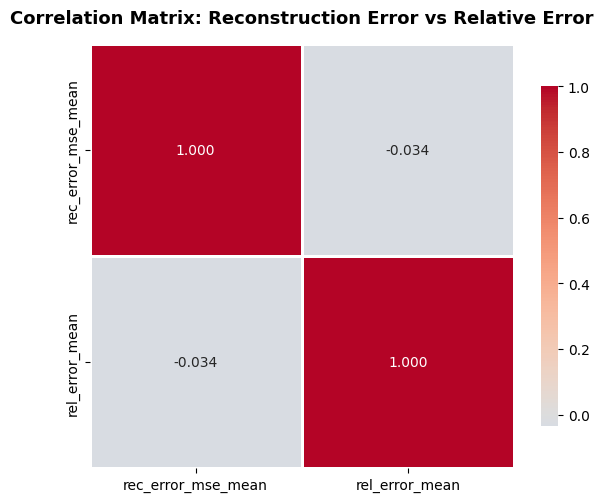


Correlation Matrix (values):
                    rec_error_mse_mean  rel_error_mean
rec_error_mse_mean              1.0000         -0.0339
rel_error_mean                 -0.0339          1.0000


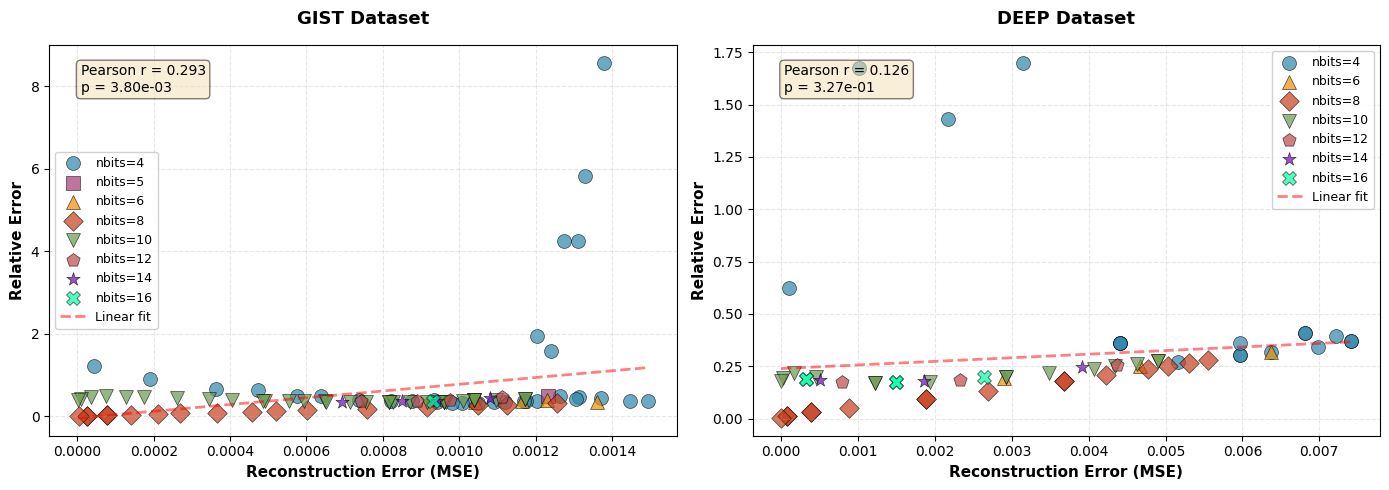

In [2]:
# ============================================================================
# Correlation Analysis: Reconstruction Error vs Relative Error
# ============================================================================

import seaborn as sns
from scipy.stats import pearsonr, spearmanr

# Define colors and markers for different nbits values (same as in plotting cells)
color_palette = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#6A994E', '#BC4749', '#7209B7', '#06FFA5']
markers = ['o', 's', '^', 'D', 'v', 'p', '*', 'X']

# Get all unique nbits values across all datasets for color mapping
all_nbits_vals = set()
for dataset_name in datasets_to_plot:
    df = dataframes[dataset_name]
    all_nbits_vals.update(df['nbits'].unique())

nbits_colors = {nbits_val: color_palette[i % len(color_palette)] 
                for i, nbits_val in enumerate(sorted(all_nbits_vals))}
nbits_markers = {nbits_val: markers[i % len(markers)] 
                 for i, nbits_val in enumerate(sorted(all_nbits_vals))}

# Combine all filtered data for correlation analysis
all_data = []
for dataset_name in datasets_to_plot:
    config = dataset_config[dataset_name]
    df = dataframes[dataset_name]
    
    # Get all rows with both reconstruction error and relative error
    df_corr = df[
        (df['train_size'] == config['train_size']) &
        (df['rec_error_mse_mean'].notna()) &
        (df['rel_error_mean'].notna())
    ].copy()
    
    if len(df_corr) > 0:
        all_data.append(df_corr)

if len(all_data) == 0:
    print("⚠️  No data available for correlation analysis")
else:
    # Combine all datasets
    df_all = pd.concat(all_data, ignore_index=True)
    
    print("="*70)
    print("Correlation Analysis: Reconstruction Error vs Relative Error")
    print("="*70)
    print(f"Total number of experiments: {len(df_all)}")
    print()
    
    # Calculate overall correlation
    if len(df_all) > 1:
        pearson_corr, pearson_p = pearsonr(df_all['rec_error_mse_mean'], df_all['rel_error_mean'])
        spearman_corr, spearman_p = spearmanr(df_all['rec_error_mse_mean'], df_all['rel_error_mean'])
        
        print("Overall Correlation (all datasets combined):")
        print(f"  Pearson correlation:  {pearson_corr:.4f} (p-value: {pearson_p:.4e})")
        print(f"  Spearman correlation: {spearman_corr:.4f} (p-value: {spearman_p:.4e})")
        print()
    
    # Calculate per-dataset correlations
    print("Per-Dataset Correlations:")
    for dataset_name in datasets_to_plot:
        config = dataset_config[dataset_name]
        df_dataset = df_all[df_all['dataset'] == dataset_name]
        
        if len(df_dataset) > 1:
            pearson_corr, pearson_p = pearsonr(df_dataset['rec_error_mse_mean'], df_dataset['rel_error_mean'])
            spearman_corr, spearman_p = spearmanr(df_dataset['rec_error_mse_mean'], df_dataset['rel_error_mean'])
            
            print(f"\n{dataset_name.upper()} Dataset (n={len(df_dataset)}):")
            print(f"  Pearson correlation:  {pearson_corr:.4f} (p-value: {pearson_p:.4e})")
            print(f"  Spearman correlation: {spearman_corr:.4f} (p-value: {spearman_p:.4e})")
    
    # Create correlation matrix with only reconstruction error and relative error
    print("\n" + "="*70)
    print("Correlation Matrix")
    print("="*70)
    
    # Select only reconstruction error and relative error columns
    corr_columns = [
        'rec_error_mse_mean',
        'rel_error_mean'
    ]
    
    # Filter to columns that exist
    available_cols = [col for col in corr_columns if col in df_all.columns]
    df_corr_matrix = df_all[available_cols]
    
    # Calculate correlation matrix
    corr_matrix = df_corr_matrix.corr()
    
    # Create visualization
    fig, ax = plt.subplots(figsize=(6, 5))
    
    # Create heatmap (no mask needed for 2x2 matrix)
    sns.heatmap(
        corr_matrix,
        annot=True,
        fmt='.3f',
        cmap='coolwarm',
        center=0,
        square=True,
        linewidths=1,
        cbar_kws={"shrink": 0.8},
        ax=ax
    )
    
    ax.set_title('Correlation Matrix: Reconstruction Error vs Relative Error', 
                 fontsize=13, fontweight='bold', pad=15)
    plt.tight_layout()
    plt.show()
    
    # Print correlation matrix as table
    print("\nCorrelation Matrix (values):")
    print(corr_matrix.round(4))
    
    # Scatter plot: Reconstruction Error vs Relative Error
    fig, axes = plt.subplots(1, len(datasets_to_plot), figsize=(7 * len(datasets_to_plot), 5))
    if len(datasets_to_plot) == 1:
        axes = [axes]
    
    for idx, dataset_name in enumerate(datasets_to_plot):
        ax = axes[idx]
        df_dataset = df_all[df_all['dataset'] == dataset_name]
        
        if len(df_dataset) > 0:
            # Color by nbits
            for nbits_val in sorted(df_dataset['nbits'].unique()):
                df_nbits = df_dataset[df_dataset['nbits'] == nbits_val]
                ax.scatter(
                    df_nbits['rec_error_mse_mean'],
                    df_nbits['rel_error_mean'],
                    marker=nbits_markers.get(nbits_val, 'o'),
                    color=nbits_colors.get(nbits_val, '#2E86AB'),
                    label=f'nbits={nbits_val}',
                    s=100,
                    alpha=0.7,
                    edgecolors='black',
                    linewidth=0.5
                )
            
            # Add correlation line
            if len(df_dataset) > 1:
                z = np.polyfit(df_dataset['rec_error_mse_mean'], df_dataset['rel_error_mean'], 1)
                p = np.poly1d(z)
                x_line = np.linspace(df_dataset['rec_error_mse_mean'].min(), 
                                    df_dataset['rec_error_mse_mean'].max(), 100)
                ax.plot(x_line, p(x_line), "r--", alpha=0.5, linewidth=2, label='Linear fit')
            
            # Calculate and display correlation
            if len(df_dataset) > 1:
                corr, p_val = pearsonr(df_dataset['rec_error_mse_mean'], df_dataset['rel_error_mean'])
                ax.text(0.05, 0.95, f'Pearson r = {corr:.3f}\np = {p_val:.2e}',
                       transform=ax.transAxes, fontsize=10,
                       verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
        
        ax.set_xlabel('Reconstruction Error (MSE)', fontsize=11, fontweight='bold')
        ax.set_ylabel('Relative Error', fontsize=11, fontweight='bold')
        ax.set_title(f'{dataset_name.upper()} Dataset', fontsize=13, fontweight='bold', pad=15)
        ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.8)
        ax.legend(fontsize=9, loc='best', framealpha=0.9)
    
    plt.tight_layout()
    plt.show()



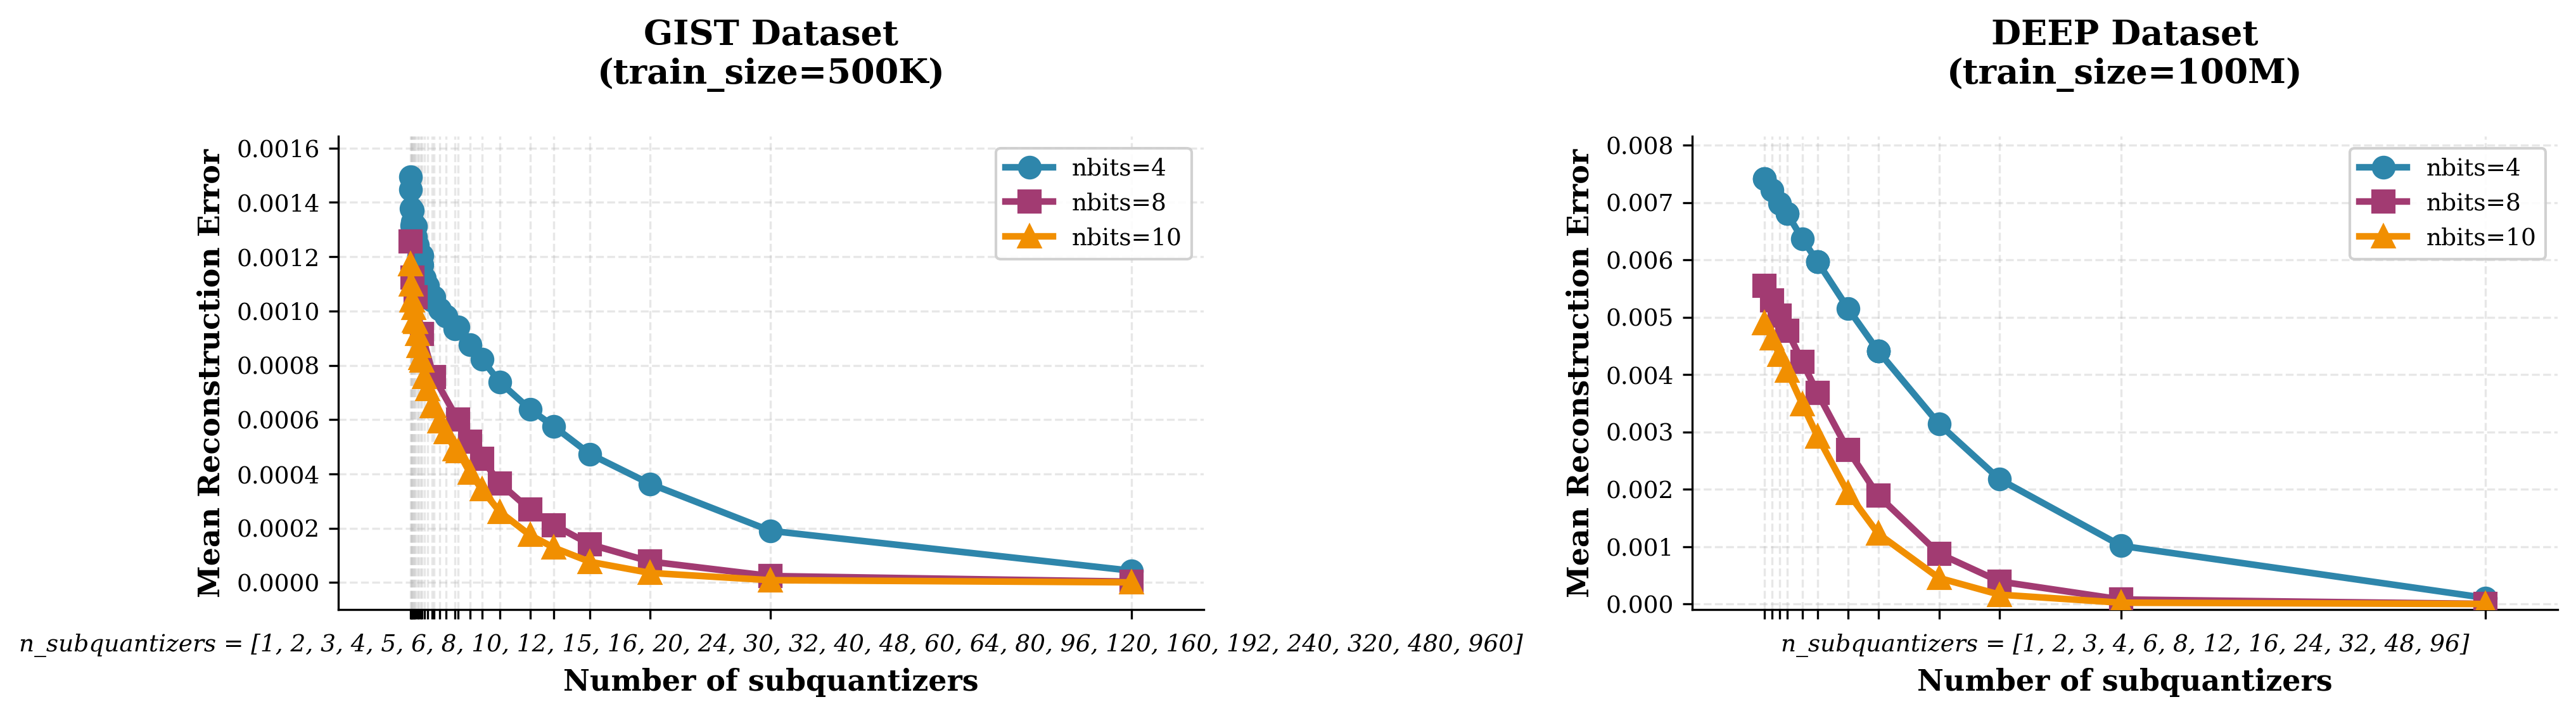


Summary: Reconstruction Error vs n_subquantizers (nbits=4, 8, 10)

GIST Dataset (nbits=4):
  n_subquantizers=  1: rec_error_mse=0.001495
  n_subquantizers=  1: rec_error_mse=0.001448
  n_subquantizers=  2: rec_error_mse=0.001378
  n_subquantizers=  3: rec_error_mse=0.001315
  n_subquantizers=  4: rec_error_mse=0.001370
  n_subquantizers=  4: rec_error_mse=0.001329
  n_subquantizers=  5: rec_error_mse=0.001306
  n_subquantizers=  6: rec_error_mse=0.001264
  n_subquantizers=  8: rec_error_mse=0.001273
  n_subquantizers=  8: rec_error_mse=0.001312
  n_subquantizers= 10: rec_error_mse=0.001241
  n_subquantizers= 12: rec_error_mse=0.001203
  n_subquantizers= 15: rec_error_mse=0.001175
  n_subquantizers= 16: rec_error_mse=0.001205
  n_subquantizers= 16: rec_error_mse=0.001170
  n_subquantizers= 20: rec_error_mse=0.001121
  n_subquantizers= 24: rec_error_mse=0.001092
  n_subquantizers= 30: rec_error_mse=0.001039
  n_subquantizers= 32: rec_error_mse=0.001050
  n_subquantizers= 40: rec_error_m

In [3]:
# ============================================================================
# Plot 1: Reconstruction Error vs n_subquantizers (for different nbits)
# ============================================================================

# Set style (paper-quality minimalist)
plt.rcParams.update({
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "font.size": 10,
    "font.family": "serif",
    "axes.labelsize": 10,
    "axes.titlesize": 12,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# Define colors and markers for different nbits values
color_palette = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#6A994E', '#BC4749', '#7209B7', '#06FFA5']
markers = ['o', 's', '^', 'D', 'v', 'p', '*', 'X']

# Create a mapping of nbits values to colors and markers
nbits_colors = {nbits_val: color_palette[i % len(color_palette)] 
                for i, nbits_val in enumerate(sorted(nbits))}
nbits_markers = {nbits_val: markers[i % len(markers)] 
                 for i, nbits_val in enumerate(sorted(nbits))}

# Create plots for each selected dataset
num_datasets = len(datasets_to_plot)

# Increase figure size for better visibility
fig, axes = plt.subplots(1, num_datasets, figsize=(7 * num_datasets, 5))

# If only one dataset, axes might be a single object
if num_datasets == 1:
    axes = [axes]

for idx, dataset_name in enumerate(datasets_to_plot):
    ax = axes[idx]
    config = dataset_config[dataset_name]
    train_size_str = f"{config['train_size']//config['divisor']}{config['letter']}"
    
    # Check if we have any data for this dataset
    has_any_data = any(len(filtered_data[dataset_name][nbits_val]) > 0 for nbits_val in nbits)
    
    if not has_any_data:
        ax.text(0.5, 0.5, f'No reconstruction error data for {dataset_name}\n(train_size={train_size_str})', 
                ha='center', va='center', transform=ax.transAxes, fontsize=12)
        ax.set_title(f'{dataset_name.upper()} Dataset\n(train_size={train_size_str})', fontweight='bold')
        continue
    
    # Plot each nbits value
    for nbits_val in sorted(nbits):
        df_filtered = filtered_data[dataset_name][nbits_val]
        
        if len(df_filtered) > 0:
            df_sorted = df_filtered.sort_values('n_subquantizers')
            ax.plot(
                df_sorted['n_subquantizers'], 
                df_sorted['rec_error_mse_mean'],
                marker=nbits_markers[nbits_val],
                markersize=8,
                linewidth=2.5,
                color=nbits_colors[nbits_val],
                label=f'nbits={nbits_val}',
                zorder=3
            )
    
    # Styling
    ax.set_xlabel('Number of subquantizers', fontsize=11, fontweight='bold', labelpad=15)
    ax.set_ylabel('Mean Reconstruction Error', fontsize=11, fontweight='bold')
    ax.set_title(f'{dataset_name.upper()} Dataset\n(train_size={train_size_str})', 
                 fontsize=13, fontweight='bold', pad=20)
    ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.8, which='both')
    ax.legend(fontsize=9, loc='best', framealpha=0.9)
    
    # Get all unique n_subquantizers values from all nbits datasets
    all_nsub = set()
    for nbits_val in nbits:
        df_filtered = filtered_data[dataset_name][nbits_val]
        if len(df_filtered) > 0:
            all_nsub.update(df_filtered['n_subquantizers'].unique())
    unique_nsub = sorted(all_nsub)
    
    # Set x-axis ticks but remove labels - show values as list instead
    ax.set_xticks(unique_nsub)
    ax.set_xticklabels([])  # Remove all tick labels
    
    # Add text box below showing all x-axis values as a list (above the xlabel)
    nsub_list_str = ', '.join([str(int(x)) for x in unique_nsub])
    ax.text(0.5, -0.05, f'n_subquantizers = [{nsub_list_str}]', 
            transform=ax.transAxes, ha='center', va='top', 
            fontsize=9, style='italic')
    
    # Set reasonable y-axis limits with some padding (considering all datasets)
    y_min = float('inf')
    y_max = float('-inf')
    for nbits_val in nbits:
        df_filtered = filtered_data[dataset_name][nbits_val]
        if len(df_filtered) > 0:
            y_min = min(y_min, df_filtered['rec_error_mse_mean'].min())
            y_max = max(y_max, df_filtered['rec_error_mse_mean'].max())
    
    y_range = y_max - y_min
    if y_range > 0:
        # ax.set_ylim(max(0, y_min - y_range * 0.05), y_max + y_range * 0.1)
        ax.set_ylim(-0.0001, y_max + y_range * 0.1)

    # Better margins (extra bottom margin for the text)
    ax.margins(x=0.1, y=0.05)

plt.tight_layout(pad=3.0, rect=[0, 0.10, 1, 0.98])
plt.show()

# Print summary statistics
nbits_str = ', '.join([str(n) for n in sorted(nbits)])
print("\n" + "="*70)
print(f"Summary: Reconstruction Error vs n_subquantizers (nbits={nbits_str})")
print("="*70)
for dataset_name in datasets_to_plot:
    has_any_data = any(len(filtered_data[dataset_name][nbits_val]) > 0 for nbits_val in nbits)
    if not has_any_data:
        continue
    
    for nbits_val in sorted(nbits):
        df_filtered = filtered_data[dataset_name][nbits_val]
        if len(df_filtered) > 0:
            df_sorted = df_filtered.sort_values('n_subquantizers')
            print(f"\n{dataset_name.upper()} Dataset (nbits={nbits_val}):")
            for _, row in df_sorted.iterrows():
                print(f"  n_subquantizers={row['n_subquantizers']:3d}: rec_error_mse={row['rec_error_mse_mean']:.6f}")



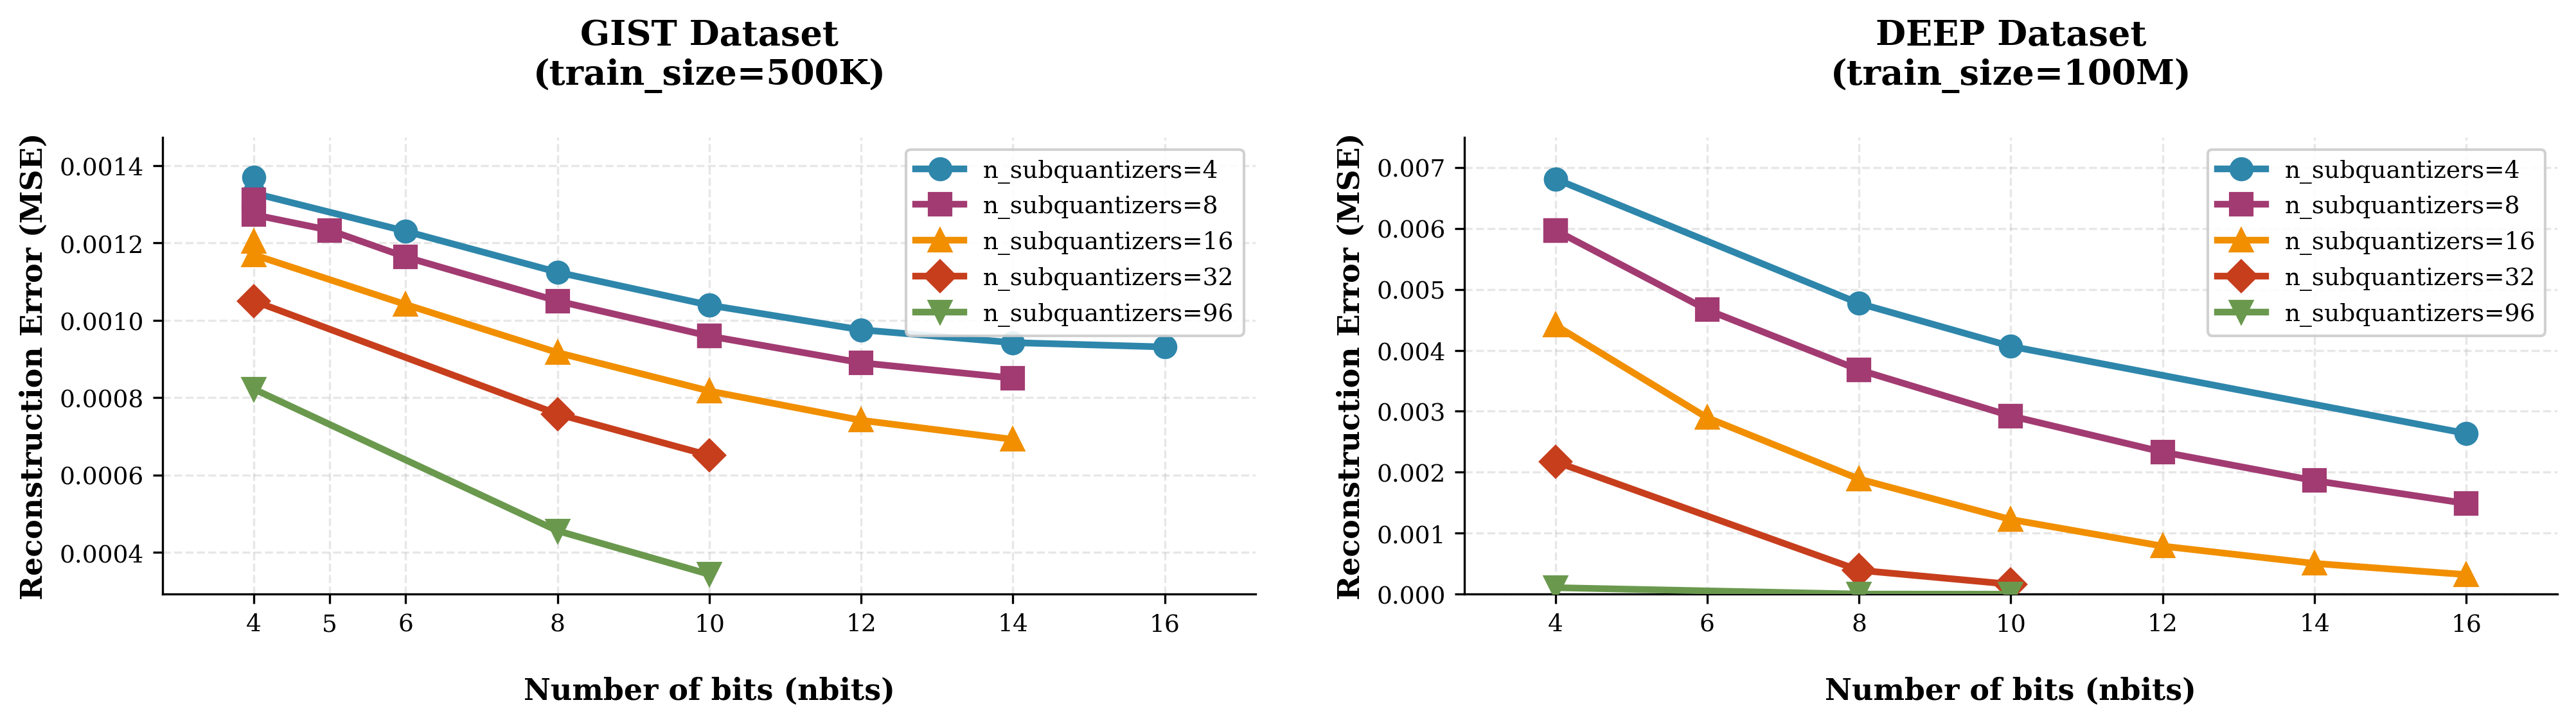


Summary: Reconstruction Error vs nbits (n_subquantizers=4, 8, 16, 32, 96)

GIST Dataset (n_subquantizers=4):
  nbits=  4: rec_error_mse=0.001370
  nbits=  4: rec_error_mse=0.001329
  nbits=  6: rec_error_mse=0.001231
  nbits=  8: rec_error_mse=0.001125
  nbits= 10: rec_error_mse=0.001039
  nbits= 10: rec_error_mse=0.001039
  nbits= 12: rec_error_mse=0.000976
  nbits= 14: rec_error_mse=0.000943
  nbits= 16: rec_error_mse=0.000931

GIST Dataset (n_subquantizers=8):
  nbits=  4: rec_error_mse=0.001312
  nbits=  4: rec_error_mse=0.001273
  nbits=  5: rec_error_mse=0.001233
  nbits=  6: rec_error_mse=0.001164
  nbits=  8: rec_error_mse=0.001050
  nbits= 10: rec_error_mse=0.000959
  nbits= 10: rec_error_mse=0.000959
  nbits= 10: rec_error_mse=0.000959
  nbits= 12: rec_error_mse=0.000890
  nbits= 14: rec_error_mse=0.000851

GIST Dataset (n_subquantizers=16):
  nbits=  4: rec_error_mse=0.001205
  nbits=  4: rec_error_mse=0.001170
  nbits=  6: rec_error_mse=0.001041
  nbits=  8: rec_error_mse=

In [4]:
# ============================================================================
# Plot 2: Reconstruction Error vs nbits (for different n_subquantizers)
# ============================================================================

# Choose which n_subquantizers values to plot
n_subquantizers_list = [ 4, 8, 16, 32, 96]  # Change this list to plot different n_subquantizers values

# Filter data for each n_subquantizers value and each dataset
filtered_data_nsubq = {dataset_name: {} for dataset_name in datasets_to_plot}

for dataset_name in datasets_to_plot:
    config = dataset_config[dataset_name]
    df = dataframes[dataset_name]
    
    for n_subq in n_subquantizers_list:
        filtered_data_nsubq[dataset_name][n_subq] = df[
            (df['n_subquantizers'] == n_subq) & 
            (df['train_size'] == config['train_size']) &
            (df['rec_error_mse_mean'].notna())  # Only include rows with reconstruction error
        ].copy()

# Create a mapping of n_subquantizers values to colors and markers
nsubq_colors = {n_subq: color_palette[i % len(color_palette)] 
                for i, n_subq in enumerate(sorted(n_subquantizers_list))}
nsubq_markers = {n_subq: markers[i % len(markers)] 
                 for i, n_subq in enumerate(sorted(n_subquantizers_list))}

# Create plots for each selected dataset
fig, axes = plt.subplots(1, num_datasets, figsize=(7 * num_datasets, 5))

# If only one dataset, axes might be a single object
if num_datasets == 1:
    axes = [axes]

for idx, dataset_name in enumerate(datasets_to_plot):
    ax = axes[idx]
    config = dataset_config[dataset_name]
    train_size_str = f"{config['train_size']//config['divisor']}{config['letter']}"
    
    # Check if we have any data for this dataset
    has_any_data = any(len(filtered_data_nsubq[dataset_name][n_subq]) > 0 for n_subq in n_subquantizers_list)
    
    if not has_any_data:
        ax.text(0.5, 0.5, f'No reconstruction error data for {dataset_name}\n(train_size={train_size_str})', 
                ha='center', va='center', transform=ax.transAxes, fontsize=12)
        ax.set_title(f'{dataset_name.upper()} Dataset\n(train_size={train_size_str})', fontweight='bold')
        continue
    
    # Plot each n_subquantizers value
    for n_subq in sorted(n_subquantizers_list):
        df_filtered = filtered_data_nsubq[dataset_name][n_subq]
        
        if len(df_filtered) > 0:
            df_sorted = df_filtered.sort_values('nbits')
            ax.plot(
                df_sorted['nbits'], 
                df_sorted['rec_error_mse_mean'],
                marker=nsubq_markers[n_subq],
                markersize=8,
                linewidth=2.5,
                color=nsubq_colors[n_subq],
                label=f'n_subquantizers={n_subq}',
                zorder=3
            )
    
    # Styling
    ax.set_xlabel('Number of bits (nbits)', fontsize=11, fontweight='bold', labelpad=15)
    ax.set_ylabel('Reconstruction Error (MSE)', fontsize=11, fontweight='bold')
    ax.set_title(f'{dataset_name.upper()} Dataset\n(train_size={train_size_str})', 
                 fontsize=13, fontweight='bold', pad=20)
    ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.8, which='both')
    ax.legend(fontsize=9, loc='best', framealpha=0.9)
    
    # Get all unique nbits values from all n_subquantizers datasets
    all_nbits = set()
    for n_subq in n_subquantizers_list:
        df_filtered = filtered_data_nsubq[dataset_name][n_subq]
        if len(df_filtered) > 0:
            all_nbits.update(df_filtered['nbits'].unique())
    unique_nbits = sorted(all_nbits)
    
    # Set x-axis ticks
    ax.set_xticks(unique_nbits)
    
    # Set reasonable y-axis limits with some padding (considering all datasets)
    y_min = float('inf')
    y_max = float('-inf')
    for n_subq in n_subquantizers_list:
        df_filtered = filtered_data_nsubq[dataset_name][n_subq]
        if len(df_filtered) > 0:
            y_min = min(y_min, df_filtered['rec_error_mse_mean'].min())
            y_max = max(y_max, df_filtered['rec_error_mse_mean'].max())
    
    y_range = y_max - y_min
    if y_range > 0:
        ax.set_ylim(max(0, y_min - y_range * 0.05), y_max + y_range * 0.1)
    # Better margins
    ax.margins(x=0.1, y=0.05)

plt.tight_layout(pad=3.0, rect=[0, 0.10, 1, 0.98])
plt.show()

# Print summary statistics
nsubq_str = ', '.join([str(n) for n in sorted(n_subquantizers_list)])
print("\n" + "="*70)
print(f"Summary: Reconstruction Error vs nbits (n_subquantizers={nsubq_str})")
print("="*70)
for dataset_name in datasets_to_plot:
    has_any_data = any(len(filtered_data_nsubq[dataset_name][n_subq]) > 0 for n_subq in n_subquantizers_list)
    if not has_any_data:
        continue
    
    for n_subq in sorted(n_subquantizers_list):
        df_filtered = filtered_data_nsubq[dataset_name][n_subq]
        if len(df_filtered) > 0:
            df_sorted = df_filtered.sort_values('nbits')
            print(f"\n{dataset_name.upper()} Dataset (n_subquantizers={n_subq}):")
            for _, row in df_sorted.iterrows():
                print(f"  nbits={row['nbits']:3d}: rec_error_mse={row['rec_error_mse_mean']:.6f}")

